# EDA Dữ Liệu BTC On-Chain (Time Series)
> **Mục tiêu**: Khám phá, hiểu, và chuẩn bị dữ liệu BTC on-chain hàng ngày làm nền tảng xây dựng mô hình dự đoán giá.

## Mục lục
1. Định nghĩa vấn đề
2. Chuẩn bị & Load dữ liệu
3. Thống kê mô tả (Ungraphic)
4. Kiểm tra chất lượng dữ liệu
5. Phân tích chuỗi thời gian đơn biến
6. Phân tích tính dừng (Stationarity)
7. Tự tương quan (ACF/PACF)
8. Phân tích phân phối & log return
9. Phân rã chuỗi thời gian (Decomposition)
10. Phân tích đa biến
11. Tóm tắt kết quả EDA

---
## 1. Định Nghĩa Vấn Đề

### 1.1 Mô tả bài toán
- **Loại bài toán**: Dự đoán giá BTC (Regression / Forecasting)
- **Dữ liệu**: BTC On-chain metrics hàng ngày 2015-01-01 → 2026-05-05
- **Mục tiêu**: Dự đoán `price_usd`

### 1.2 Ý nghĩa các features

| Feature | Mô tả | Ghi chú |
|---------|-------|---------|
| `price_usd` | Giá Bitcoin (TARGET) | USD |
| `active_addresses` | Số ví hoạt động trong ngày | Đo nhu cầu sử dụng mạng |
| `tx_count` | Số giao dịch trên blockchain | Đo hoạt động mạng |
| `hash_rate` | Sức mạnh tính toán của mạng | Đo bảo mật mạng |
| `supply_current` | Tổng BTC đang lưu hành | Tăng dần đến 21M |
| `fee_usd` | Tổng phí giao dịch | Đo tắc nghẽn mạng |
| `difficulty` | Độ khó đào coin | Điều chỉnh mỗi ~2 tuần |
| `miner_revenue_usd` | Doanh thu thợ đào | Block reward + fees |
| `estimated_transaction_volume_usd` | Khối lượng giao dịch | USD |

### 1.3 Tại sao EDA Time Series KHÁC với EDA thông thường?

| Tiêu chí | EDA Thông thường (Iris) | EDA Time Series (BTC) |
|---|---|---|
| Thứ tự dữ liệu | Không quan trọng | ⚠️ RẤT QUAN TRỌNG |
| Train/Test split | Random | Chronological (không random) |
| Phân phối | Histogram đơn giản | Log-return, kiểm tra fat tail |
| Tương quan | Pearson đủ dùng | Cần lag correlation, cross-correlation |
| Kiểm tra đặc biệt | Không cần | Stationarity, ACF/PACF, Decomposition |
| Outlier | Boxplot tĩnh | Xét trong ngữ cảnh thời gian |

---
## 2. Chuẩn Bị & Load Dữ Liệu

### 2.1 Khai báo thư viện

In [22]:
# ====== KHAI BÁO THƯ VIỆN ======
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from scipy.stats import jarque_bera

# Statsmodels - dành riêng cho time series
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import warnings
warnings.filterwarnings("ignore")

# ====== CẤU HÌNH HIỂN THỊ ======
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.size"] = 11
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.style.use("seaborn-v0_8-whitegrid")

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
print("Đã load thư viện thanh cong!")

Đã load thư viện thanh cong!


### 2.2 Nạp & tiền xử lý dữ liệu

In [23]:
# ====== NẠP DỮ LIỆU ======
DATA_PATH = "../data/preprocessed/btc_onchain_daily_preprocessed.csv"  # Thay đường dẫn nếu cần
df = pd.read_csv(DATA_PATH)

# Parse cột date và sort theo thứ tự thời gian (BẮT BUỘC với time series)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

# Tạo thêm biến thời gian hữu ích
df["year"]      = df["date"].dt.year
df["month"]     = df["date"].dt.month
df["quarter"]   = df["date"].dt.quarter
df["dayofweek"] = df["date"].dt.dayofweek  # 0=Monday

# Tạo log_return - biến động giá hàng ngày (quan trọng cho time series)
df["log_return"] = np.log(df["price_usd"] / df["price_usd"].shift(1))
df["pct_return"] = df["price_usd"].pct_change() * 100

print(f"Du lieu san sang: {df.shape[0]:,} dong x {df.shape[1]} cot")
print(f"Khoang thoi gian: {df['date'].min().date()} --> {df['date'].max().date()}")
print(f"Tong so ngay: {(df['date'].max() - df['date'].min()).days:,} ngay")
df.head(3)

Du lieu san sang: 4,143 dong x 16 cot
Khoang thoi gian: 2015-01-01 --> 2026-05-05
Tong so ngay: 4,142 ngay


,date,price_usd,active_addresses,tx_count,hash_rate,supply_current,fee_usd,difficulty,miner_revenue_usd,estimated_transaction_volume_usd,year,month,quarter,dayofweek,log_return,pct_return
0,2015-01-01,315,145765,60177,333345,13675615,2989,40640955017,1519572,25914596,2015,1,1,3,NaN,NaN
1,2015-01-02,316,212932,83050,333345,13679740,4047,40640955017,1475784,41275152,2015,1,1,4,0.00,0.32
2,2015-01-03,286,241755,81404,327284,13683790,4357,40640955017,1586907,90356063,2015,1,1,5,-0.10,-9.49


---
## 3. Thống Kê Mô Tả (Ungraphic Approach)

### 3.1 Tổng quan dữ liệu

In [24]:
# ====== TỔNG QUAN ======
print(f"SHAPE: {df.shape[0]:,} rows x {df.shape[1]} columns")
print()
print("KIEU DU LIEU:")
print(df.dtypes)
print()
print("5 DONG DAU:")
display(df[["date","price_usd","active_addresses","tx_count","hash_rate",
            "supply_current","fee_usd","difficulty","miner_revenue_usd",
            "estimated_transaction_volume_usd"]].head())
print()
print("5 DONG CUOI:")
display(df[["date","price_usd","active_addresses","tx_count","hash_rate",
            "supply_current","fee_usd","difficulty","miner_revenue_usd",
            "estimated_transaction_volume_usd"]].tail())

SHAPE: 4,143 rows x 16 columns

KIEU DU LIEU:
date                                datetime64[us]
price_usd                                    int64
active_addresses                             int64
tx_count                                     int64
hash_rate                                    int64
supply_current                               int64
fee_usd                                      int64
difficulty                                   int64
miner_revenue_usd                            int64
estimated_transaction_volume_usd             int64
year                                         int32
month                                        int32
quarter                                      int32
dayofweek                                    int32
log_return                                 float64
pct_return                                 float64
dtype: object

5 DONG DAU:


,date,price_usd,active_addresses,tx_count,hash_rate,supply_current,fee_usd,difficulty,miner_revenue_usd,estimated_transaction_volume_usd
0,2015-01-01,315,145765,60177,333345,13675615,2989,40640955017,1519572,25914596
1,2015-01-02,316,212932,83050,333345,13679740,4047,40640955017,1475784,41275152
2,2015-01-03,286,241755,81404,327284,13683790,4357,40640955017,1586907,90356063
3,2015-01-04,263,235011,82769,347487,13688090,7190,40640955017,1632203,82599915
4,2015-01-05,275,242515,95721,315163,13691990,4616,40640955017,1202039,68422951



5 DONG CUOI:


,date,price_usd,active_addresses,tx_count,hash_rate,supply_current,fee_usd,difficulty,miner_revenue_usd,estimated_transaction_volume_usd
4138,2026-05-01,78133,751425,597457,1064992342,20023245,216951,135594876535256,36372876,7051613813
4139,2026-05-02,78713,620486,529423,896831741,20023670,220106,132770520277053,36532352,2098986460
4140,2026-05-03,78649,583469,596099,1000953351,20024145,223262,132472011079032,36691827,1787557345
4141,2026-05-04,79826,722079,567474,981197687,20024611,226418,132472011079032,36851303,7880460115
4142,2026-05-05,80937,721256,589261,987782912,20025079,229573,132472011079032,37010778,8837709858


### 3.2 Thống kê mô tả chi tiết (bổ sung skewness & kurtosis)

In [25]:
# ====== THONG KE MO TA ======
numeric_cols = ["price_usd","active_addresses","tx_count","hash_rate",
                "supply_current","fee_usd","difficulty",
                "miner_revenue_usd","estimated_transaction_volume_usd"]

desc = df[numeric_cols].describe().T
desc["skewness"] = df[numeric_cols].skew()
desc["kurtosis"] = df[numeric_cols].kurtosis()
desc["cv%"]      = (df[numeric_cols].std() / df[numeric_cols].mean() * 100).round(1)

display(desc)

print("""
GIAI THICH CAC CHI SO:
  mean     : Gia tri trung binh
  std      : Do lech chuan - do muc do bien dong
  skewness : Do lech phan phoi (>0: lech phai, <0: lech trai, ly tuong ~ 0)
  kurtosis : Do nhon phan phoi (>0: duoi nang/fat tail, ly tuong ~ 0)
  cv%      : He so bien thien = std/mean x 100 (do muc bien dong tuong doi)

NHAN XET:
  fee_usd: skew=10.99, kurt=263 --> Cuc ky lech, fat tail manh (do congestion dot ngot)
  estimated_tx_volume: skew=2.47, kurt=11.96 --> Lech phai manh
  hash_rate & difficulty: skew > 1.3 --> Lech phai (tang manh trong thoi gian gan day)
""")

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis,cv%
price_usd,"4,143.00","28,999.94","32,408.80",176.00,"3,824.00","11,993.00","46,509.00","124,824.00",1.17,0.29,111.80
active_addresses,"4,143.00","742,105.78","222,084.38","145,765.00","612,411.00","744,786.00","911,577.50","1,366,494.00",-0.28,-0.24,29.90
tx_count,"4,143.00","312,684.95","129,864.35","60,177.00","231,075.50","289,249.00","360,940.50","928,131.00",1.08,1.58,41.50
hash_rate,"4,143.00","253,572,091.08","316,679,089.50","257,929.00","10,178,226.50","118,964,875.00","376,489,956.50","1,305,499,728.00",1.34,0.60,124.90
supply_current,"4,143.00","17,935,488.74","1,740,297.47","13,675,615.00","16,659,761.50","18,477,967.00","19,420,374.50","20,025,079.00",-0.72,-0.56,9.70
fee_usd,"4,143.00","1,071,987.12","2,518,365.81","2,818.00","142,977.00","399,168.00","851,903.50","81,050,337.00",10.99,263.88,234.90
difficulty,"4,143.00","35,088,789,385,458.64","43,776,750,821,718.79","40,640,955,017.00","1,347,001,430,558.00","16,552,923,967,337.00","52,328,312,063,444.00","155,973,032,196,072.00",1.33,0.50,124.80
miner_revenue_usd,"4,143.00","22,673,368.95","18,040,968.18","672,812.00","7,100,987.50","18,584,576.00","36,288,666.00","107,755,900.00",0.61,-0.53,79.60
estimated_transaction_volume_usd,"4,143.00","3,279,597,106.72","4,109,043,321.45","24,652,241.00","537,950,896.50","1,663,806,011.00","4,477,868,019.50","58,388,673,978.00",2.47,11.96,125.30



GIAI THICH CAC CHI SO:
  mean     : Gia tri trung binh
  std      : Do lech chuan - do muc do bien dong
  skewness : Do lech phan phoi (>0: lech phai, <0: lech trai, ly tuong ~ 0)
  kurtosis : Do nhon phan phoi (>0: duoi nang/fat tail, ly tuong ~ 0)
  cv%      : He so bien thien = std/mean x 100 (do muc bien dong tuong doi)

NHAN XET:
  fee_usd: skew=10.99, kurt=263 --> Cuc ky lech, fat tail manh (do congestion dot ngot)
  estimated_tx_volume: skew=2.47, kurt=11.96 --> Lech phai manh
  hash_rate & difficulty: skew > 1.3 --> Lech phai (tang manh trong thoi gian gan day)



---
## 4. Kiểm Tra Chất Lượng Dữ Liệu

> Với time series, ngoài null/duplicate còn phải kiểm tra **tính liên tục thời gian**.

In [26]:
# ====== KIEM TRA CHAT LUONG DU LIEU ======
print("1. KIEM TRA NULL/NaN:")
print(df.isnull().sum())

print()
print("2. KIEM TRA TRUNG LAP:")
n_dup = df.duplicated().sum()
print(f"So dong trung lap: {n_dup}")

print()
print("3. KIEM TRA TINH LIEN TUC THOI GIAN (Dac trung Time Series):")
date_diff = df["date"].diff().dt.days
missing_dates = date_diff[date_diff > 1]
print(f"Khoang cach toi da giua 2 ngay lien tiep: {date_diff.max():.0f} ngay")
print(f"So khoang trong (gap > 1 ngay): {len(missing_dates)}")
if len(missing_dates) == 0:
    print("Du lieu lien tuc hang ngay, khong co khoang trong!")
else:
    print("CAC KHOANG TRONG PHAT HIEN:")
    display(df.loc[missing_dates.index, ["date"]].assign(gap_days=missing_dates))

print()
print("4. THONG KE THEO NAM:")
yearly = df.groupby("year").agg(
    n_days=("date","count"),
    price_min=("price_usd","min"),
    price_max=("price_usd","max"),
    price_mean=("price_usd","mean")
).round(0)
display(yearly)

1. KIEM TRA NULL/NaN:
date                                0
price_usd                           0
active_addresses                    0
tx_count                            0
hash_rate                           0
supply_current                      0
fee_usd                             0
difficulty                          0
miner_revenue_usd                   0
estimated_transaction_volume_usd    0
year                                0
month                               0
quarter                             0
dayofweek                           0
log_return                          1
pct_return                          1
dtype: int64

2. KIEM TRA TRUNG LAP:
So dong trung lap: 0

3. KIEM TRA TINH LIEN TUC THOI GIAN (Dac trung Time Series):
Khoang cach toi da giua 2 ngay lien tiep: 1 ngay
So khoang trong (gap > 1 ngay): 0
Du lieu lien tuc hang ngay, khong co khoang trong!

4. THONG KE THEO NAM:


,n_days,price_min,price_max,price_mean
year,,,,
2015,365,176,465,273.00
2016,366,366,980,568.00
2017,365,788,19641,"3,994.00"
2018,365,3185,17104,"7,519.00"
2019,365,3359,12863,"7,365.00"
2020,366,4959,29023,"11,119.00"
2021,365,29381,67542,"47,439.00"
2022,365,15758,47560,"28,192.00"
2023,365,16607,44205,"28,859.00"


---
## 5. Phân Tích Chuỗi Thời Gian Đơn Biến

> **Nguyên tắc cốt lõi**: Với time series, luôn **vẽ dữ liệu theo trục thời gian** trước tiên. Histogram đơn thuần bỏ qua thứ tự thời gian — thứ tự này chứa thông tin cực kỳ quan trọng.

### 5.1 Xu hướng giá BTC

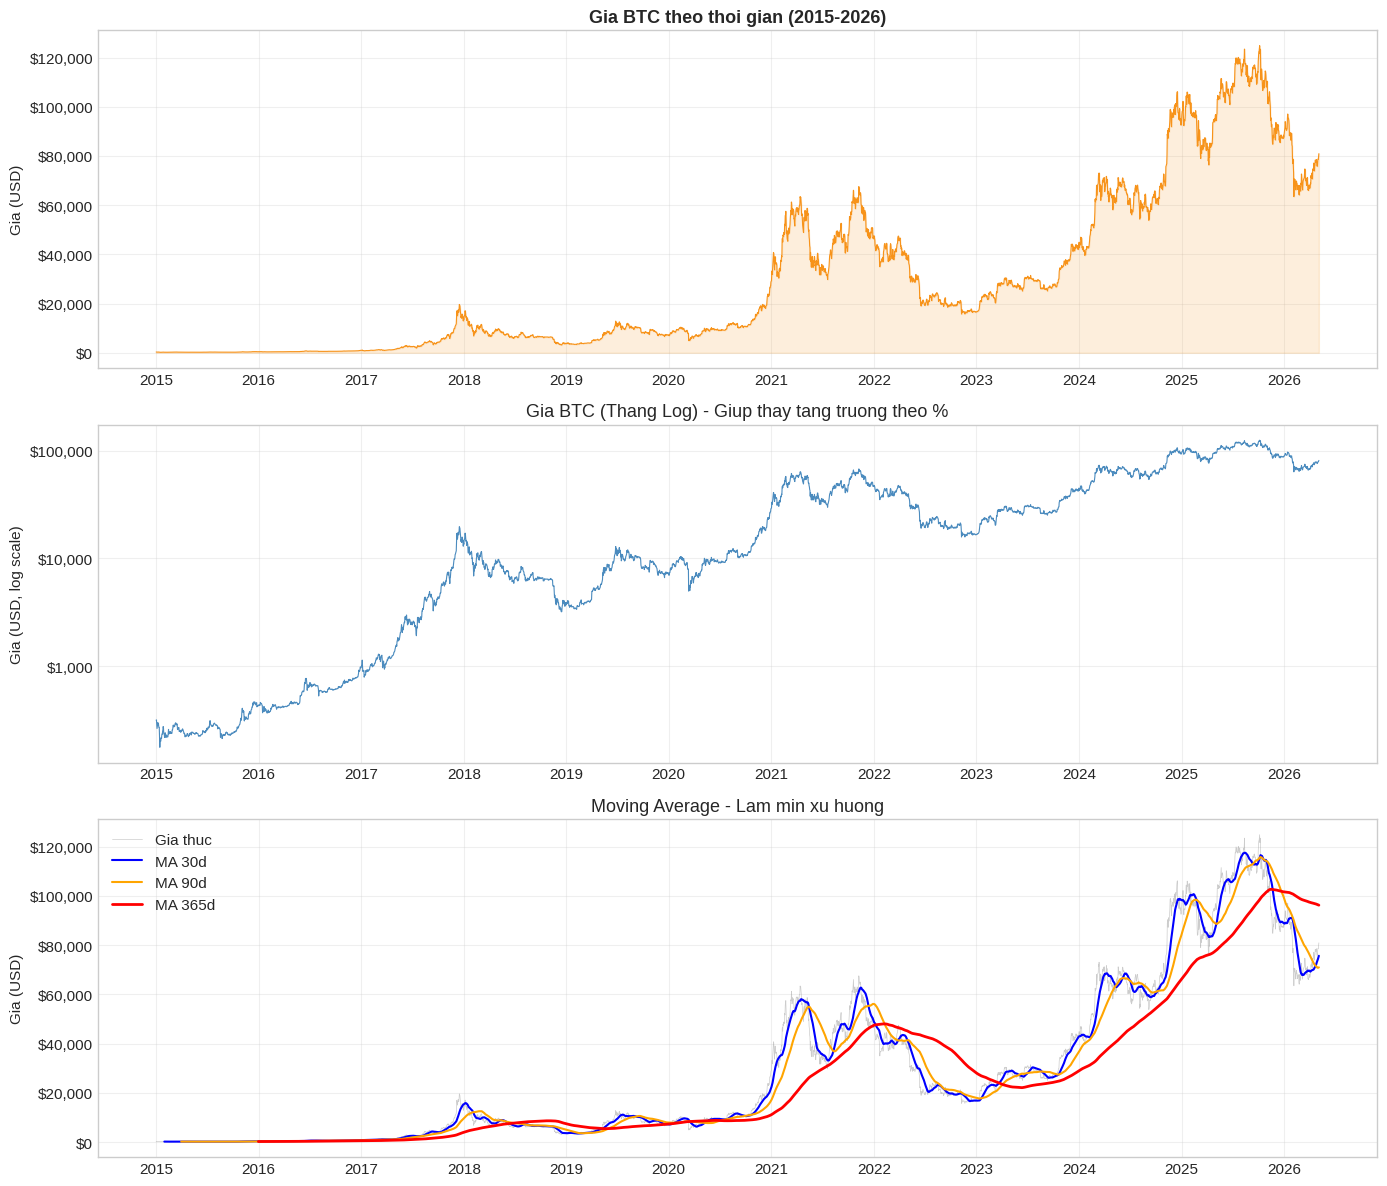


NHAN XET:
  Do thi tuyen tinh : thay ro bull market 2017, 2020-21, 2024-25
  Thang log         : BTC tang ~400x tu 2015 den 2025
  Moving Average    : MA365 la trend dai han; khi MA30 cat len MA90 -> bao hieu tang



In [27]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Plot 1: Gia BTC
ax1 = axes[0]
ax1.plot(df["date"], df["price_usd"], color="#F7931A", linewidth=0.8)
ax1.fill_between(df["date"], df["price_usd"], alpha=0.15, color="#F7931A")
ax1.set_title("Gia BTC theo thoi gian (2015-2026)", fontsize=13, fontweight="bold")
ax1.set_ylabel("Gia (USD)")
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"${x:,.0f}"))

# Plot 2: Log scale
ax2 = axes[1]
ax2.semilogy(df["date"], df["price_usd"], color="#4B8BBE", linewidth=0.8)
ax2.set_title("Gia BTC (Thang Log) - Giup thay tang truong theo %", fontsize=13)
ax2.set_ylabel("Gia (USD, log scale)")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"${x:,.0f}"))

# Plot 3: Moving Average
ax3 = axes[2]
ax3.plot(df["date"], df["price_usd"], color="gray", alpha=0.4, linewidth=0.5, label="Gia thuc")
ax3.plot(df["date"], df["price_usd"].rolling(30).mean(),  color="blue",   lw=1.5, label="MA 30d")
ax3.plot(df["date"], df["price_usd"].rolling(90).mean(),  color="orange", lw=1.5, label="MA 90d")
ax3.plot(df["date"], df["price_usd"].rolling(365).mean(), color="red",    lw=2,   label="MA 365d")
ax3.set_title("Moving Average - Lam min xu huong", fontsize=13)
ax3.set_ylabel("Gia (USD)")
ax3.legend(loc="upper left")
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"${x:,.0f}"))

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()

print("""
NHAN XET:
  Do thi tuyen tinh : thay ro bull market 2017, 2020-21, 2024-25
  Thang log         : BTC tang ~400x tu 2015 den 2025
  Moving Average    : MA365 la trend dai han; khi MA30 cat len MA90 -> bao hieu tang
""")

### 5.2 Phân tích các features on-chain

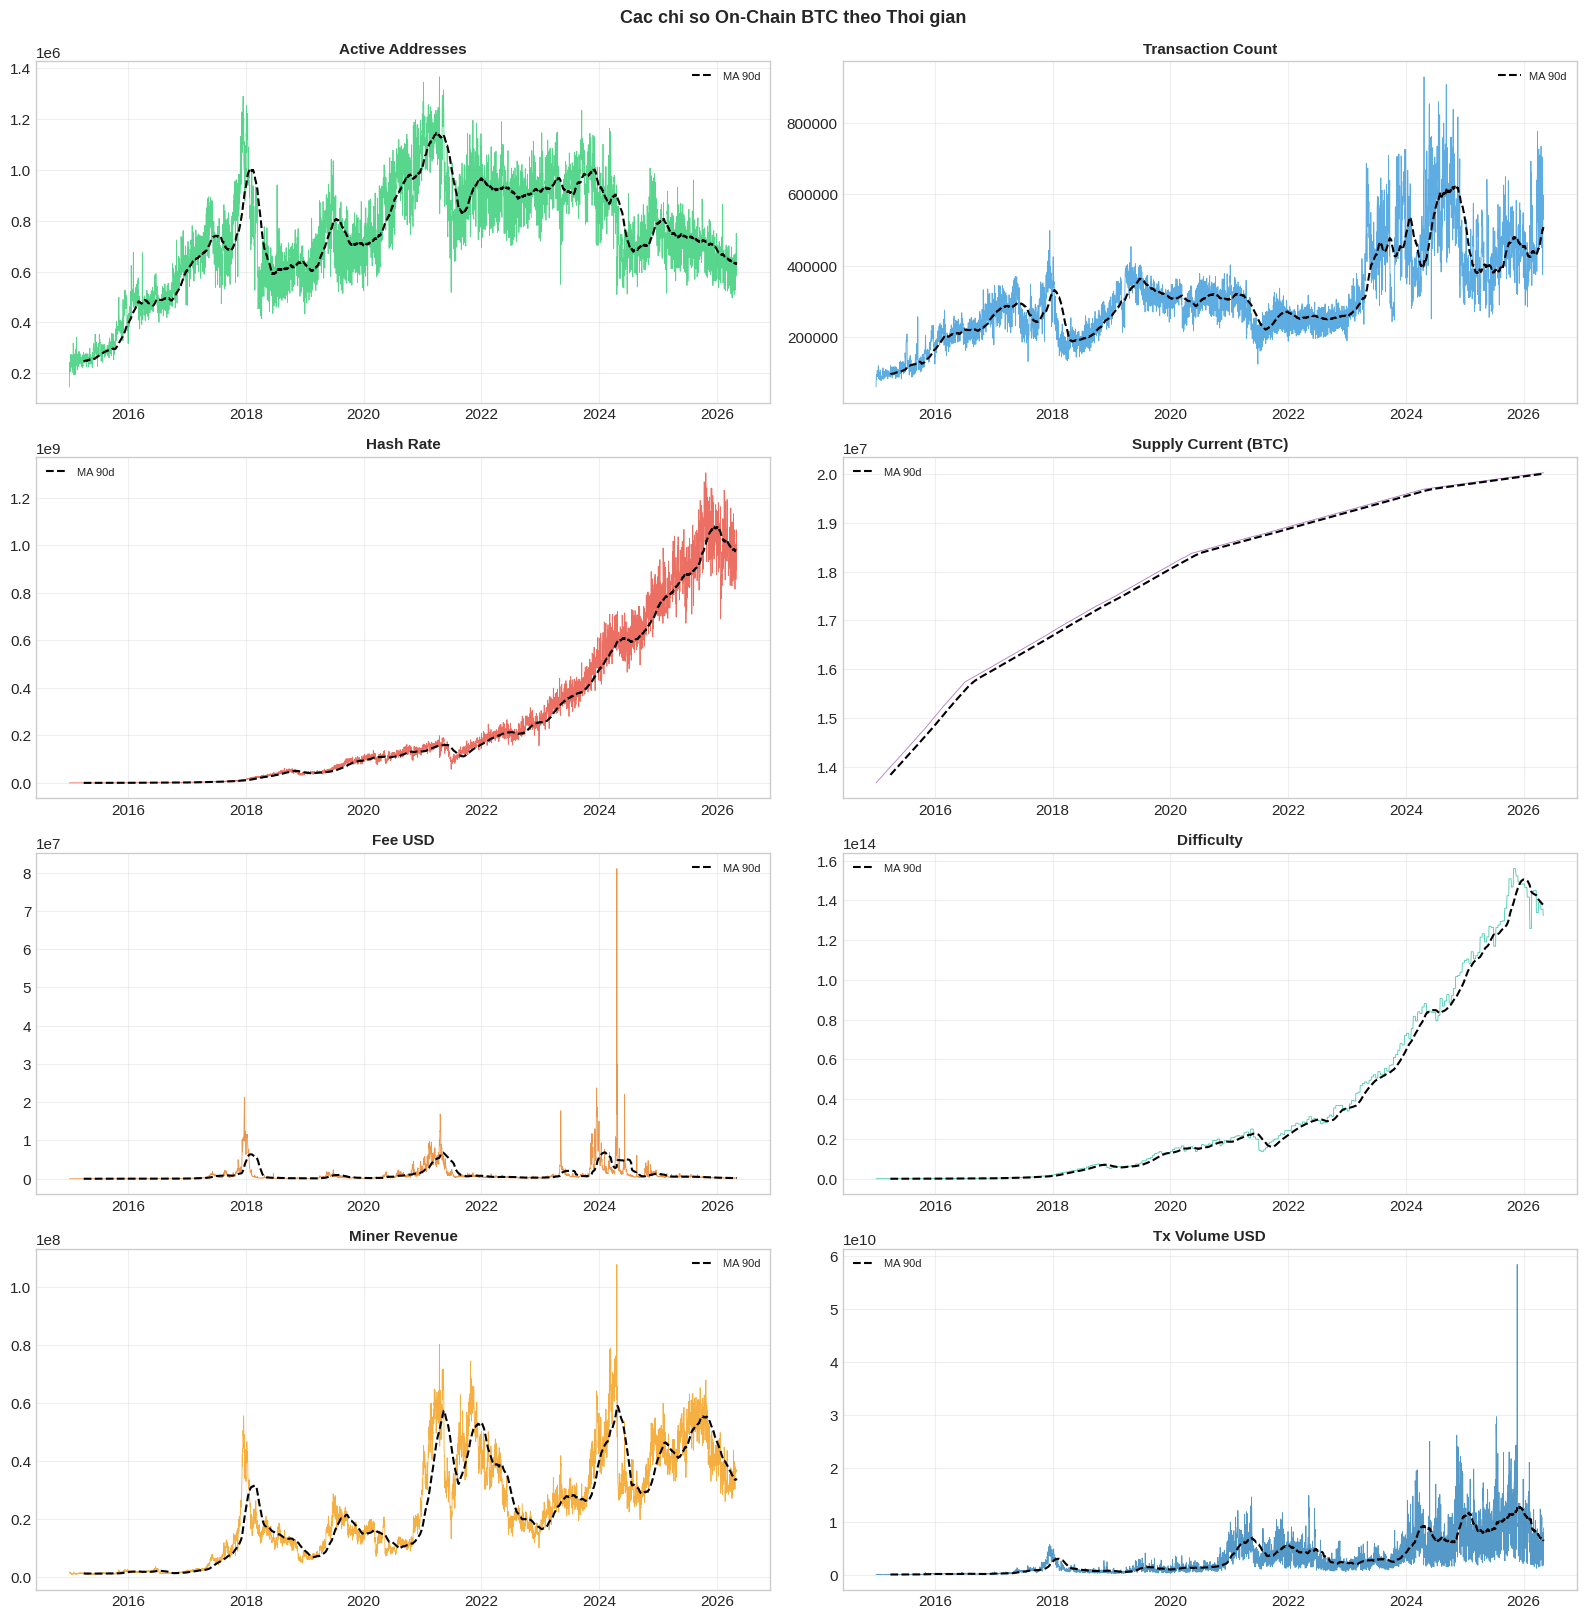


NHAN XET:
  Hash rate & Difficulty: tang lien tuc -> mang BTC ngay cang manh hon
  Supply current        : tang cham va hoi tu ve ~21M BTC (halving effect)
  Active addresses/tx   : co tinh chu ky, tang manh trong bull market
  Fee & Miner revenue   : bien dong cuc manh, phu thuoc congestion mang



In [28]:
fig, axes = plt.subplots(4, 2, figsize=(16, 16))
axes = axes.flatten()

onchain_features = [
    ("active_addresses",                 "Active Addresses",          "#2ECC71"),
    ("tx_count",                         "Transaction Count",          "#3498DB"),
    ("hash_rate",                        "Hash Rate",                  "#E74C3C"),
    ("supply_current",                   "Supply Current (BTC)",       "#9B59B6"),
    ("fee_usd",                          "Fee USD",                    "#E67E22"),
    ("difficulty",                       "Difficulty",                 "#1ABC9C"),
    ("miner_revenue_usd",                "Miner Revenue",              "#F39C12"),
    ("estimated_transaction_volume_usd", "Tx Volume USD",              "#2980B9"),
]

for i, (col, title, color) in enumerate(onchain_features):
    ax = axes[i]
    ax.plot(df["date"], df[col], color=color, linewidth=0.6, alpha=0.8)
    ax.plot(df["date"], df[col].rolling(90).mean(), color="black", lw=1.5,
            linestyle="--", label="MA 90d")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.legend(fontsize=8)

plt.tight_layout()
plt.suptitle("Cac chi so On-Chain BTC theo Thoi gian", y=1.01, fontsize=13, fontweight="bold")
plt.show()

print("""
NHAN XET:
  Hash rate & Difficulty: tang lien tuc -> mang BTC ngay cang manh hon
  Supply current        : tang cham va hoi tu ve ~21M BTC (halving effect)
  Active addresses/tx   : co tinh chu ky, tang manh trong bull market
  Fee & Miner revenue   : bien dong cuc manh, phu thuoc congestion mang
""")

---
## 6. Phân Tích Tính Dừng (Stationarity)

> **Khai niem quan trong nhat trong Time Series EDA!**
>
> **Chuan dong (Stationary)**: mean va variance khong thay doi theo thoi gian.
> - Hau het mo hinh time series (ARIMA, ML) yeu cau du lieu phai dung.
> - Gia BTC khong dung -> phai bien doi truoc khi mo hinh hoa.
>
> **Kiem dinh ADF**: H0: Khong dung (co unit root); H1: Dung
> - p-value < 0.05: bac bo H0 -> chuoi dung

In [29]:
from statsmodels.tsa.stattools import adfuller, kpss

def test_stationarity(series, name):
    series = series.dropna()
    adf_result  = adfuller(series, autolag="AIC")
    kpss_result = kpss(series, regression="c", nlags="auto")
    
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  ADF  | Statistic: {adf_result[0]:8.4f} | p-value: {adf_result[1]:.6f}", end="")
    print(f"  {'[DUNG]' if adf_result[1] < 0.05 else '[KHONG DUNG]'}")
    print(f"  KPSS | Statistic: {kpss_result[0]:8.4f} | p-value: {kpss_result[1]:.4f}", end="")
    print(f"  {'[DUNG]' if kpss_result[1] >= 0.05 else '[KHONG DUNG]'}")

test_stationarity(df["price_usd"],  "Gia BTC (price_usd)")
test_stationarity(df["log_return"], "Log Return ln(Pt/Pt-1)")
df["price_diff1"] = df["price_usd"].diff()
test_stationarity(df["price_diff1"], "Sai phan bac 1 (delta_price)")

print("""
GIAI THICH:
  price_usd   : KHONG DUNG (ADF p=0.756) -> khong the dua thang vao ARIMA
  log_return  : DUNG (ADF p~0) -> dung duoc cho mo hinh statistical
  sai phan b1 : Thuong cung dung -> tuy bai toan ma chon

  Voi mo hinh ML (LSTM/XGBoost): dung lag features + rolling stats cua price goc
  Voi mo hinh ARIMA           : phai lam dung (log-return hoac differencing)
""")


  Gia BTC (price_usd)
  ADF  | Statistic:  -0.9912 | p-value: 0.756473  [KHONG DUNG]
  KPSS | Statistic:   7.5069 | p-value: 0.0100  [KHONG DUNG]

  Log Return ln(Pt/Pt-1)
  ADF  | Statistic: -45.5434 | p-value: 0.000000  [DUNG]
  KPSS | Statistic:   0.1728 | p-value: 0.1000  [DUNG]

  Sai phan bac 1 (delta_price)
  ADF  | Statistic:  -9.8023 | p-value: 0.000000  [DUNG]
  KPSS | Statistic:   0.0867 | p-value: 0.1000  [DUNG]

GIAI THICH:
  price_usd   : KHONG DUNG (ADF p=0.756) -> khong the dua thang vao ARIMA
  log_return  : DUNG (ADF p~0) -> dung duoc cho mo hinh statistical
  sai phan b1 : Thuong cung dung -> tuy bai toan ma chon

  Voi mo hinh ML (LSTM/XGBoost): dung lag features + rolling stats cua price goc
  Voi mo hinh ARIMA           : phai lam dung (log-return hoac differencing)



### 6.2 Trực quan hóa tính dừng

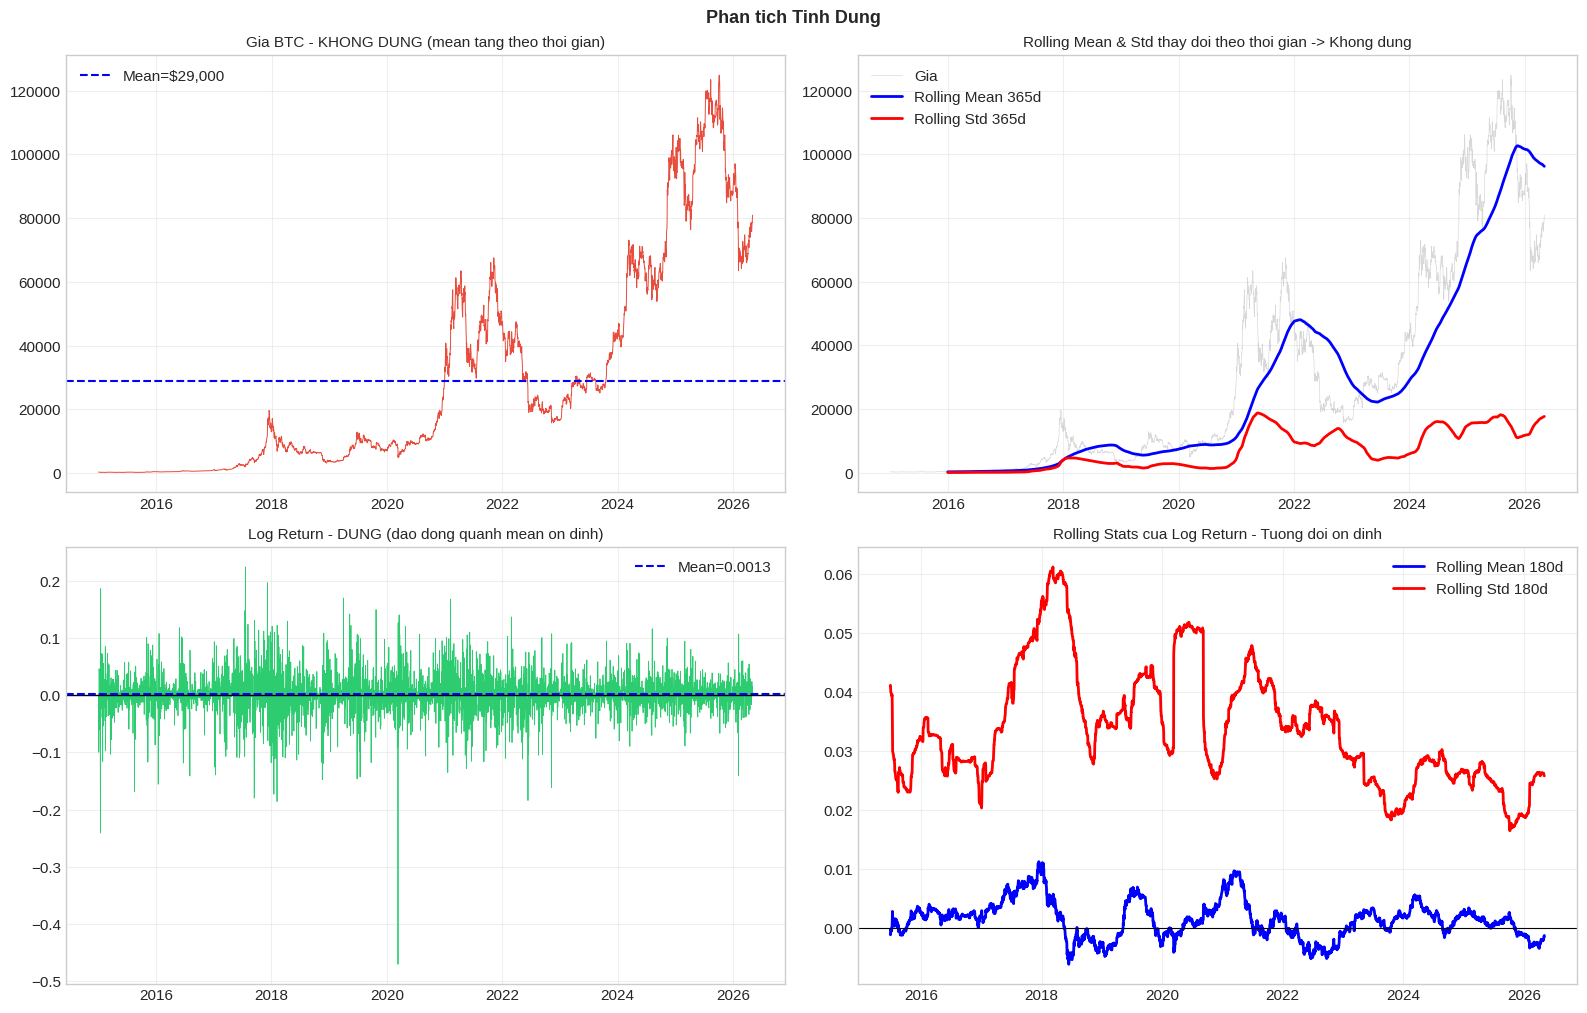

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

ax = axes[0, 0]
ax.plot(df["date"], df["price_usd"], color="#E74C3C", linewidth=0.7)
ax.axhline(df["price_usd"].mean(), color="blue", linestyle="--",
           label=f"Mean=${df['price_usd'].mean():,.0f}")
ax.set_title("Gia BTC - KHONG DUNG (mean tang theo thoi gian)", fontsize=11)
ax.legend()

ax2 = axes[0, 1]
roll_mean = df["price_usd"].rolling(365).mean()
roll_std  = df["price_usd"].rolling(365).std()
ax2.plot(df["date"], df["price_usd"], alpha=0.3, color="gray", lw=0.5, label="Gia")
ax2.plot(df["date"], roll_mean, color="blue",   lw=2, label="Rolling Mean 365d")
ax2.plot(df["date"], roll_std,  color="red",    lw=2, label="Rolling Std 365d")
ax2.set_title("Rolling Mean & Std thay doi theo thoi gian -> Khong dung", fontsize=11)
ax2.legend()

ax3 = axes[1, 0]
ax3.plot(df["date"], df["log_return"], color="#2ECC71", linewidth=0.6)
ax3.axhline(0, color="black", lw=1)
ax3.axhline(df["log_return"].mean(), color="blue", linestyle="--",
            label=f"Mean={df['log_return'].mean():.4f}")
ax3.set_title("Log Return - DUNG (dao dong quanh mean on dinh)", fontsize=11)
ax3.legend()

ax4 = axes[1, 1]
ax4.plot(df["date"], df["log_return"].rolling(180).mean(), color="blue",  lw=2, label="Rolling Mean 180d")
ax4.plot(df["date"], df["log_return"].rolling(180).std(),  color="red",   lw=2, label="Rolling Std 180d")
ax4.axhline(0, color="black", lw=0.8)
ax4.set_title("Rolling Stats cua Log Return - Tuong doi on dinh", fontsize=11)
ax4.legend()

for ax in axes.flatten():
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.suptitle("Phan tich Tinh Dung", y=1.01, fontsize=13, fontweight="bold")
plt.show()

---
## 7. Tự Tương Quan — ACF & PACF

> **ACF**: Đo tương quan của chuỗi với chính nó tại các độ trễ (lag) khác nhau.
>
> **PACF**: Tương tự ACF nhưng loại bỏ ảnh hưởng của các lag trung gian.
>
> **Ứng dụng**: Giúp xác định bậc p, q cho ARIMA; xác định số lag cần cho ML.

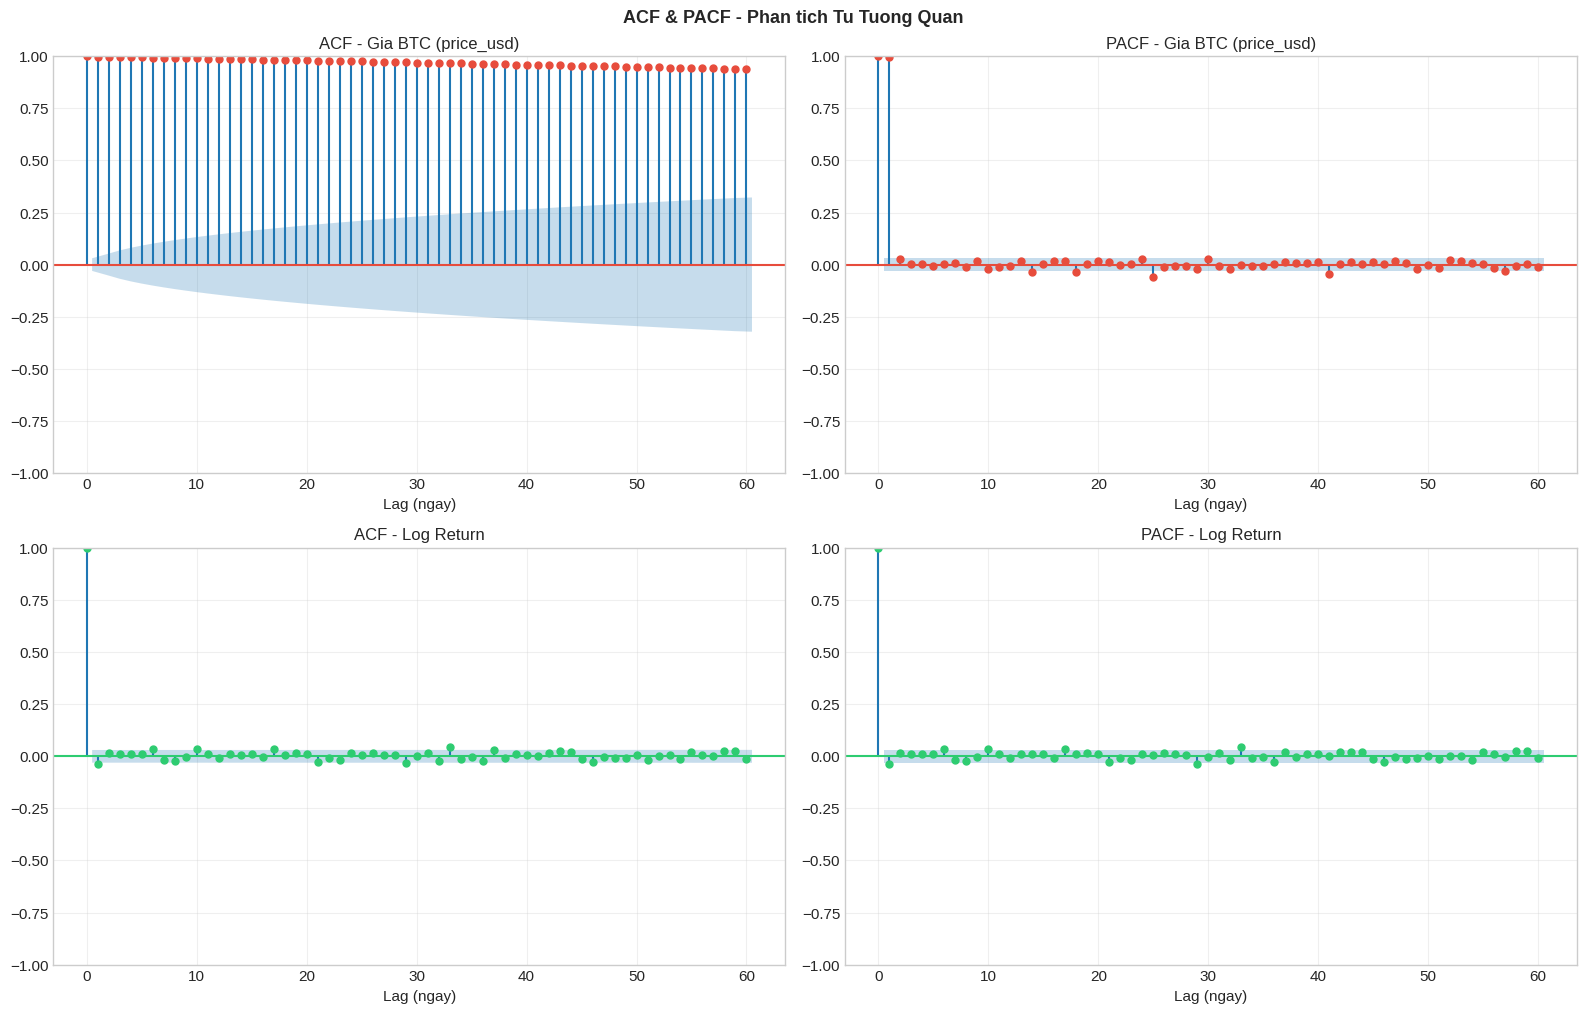


CACH DOC ACF/PACF:
  Vung mau xanh = confidence interval (95%)
  Cot vuot ra ngoai vung xanh -> co tuong quan thong ke tai lag do

NHAN XET:
  ACF(price_usd) : Tat ca lag deu cao -> xac nhan KHONG DUNG (decay rat cham)
  ACF(log_return): Hau het lag khong dang ke -> xac nhan DUNG
  PACF(price_usd): Chi lag 1 lon -> goi y AR(1) / Random Walk

UNG DUNG XAY DUNG MO HINH:
  ARIMA: Dung ACF/PACF cua log_return de xac dinh (p,d,q)
  ML   : Dung cac lag 1, 7, 14, 30 lam features



In [31]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

plot_acf(df["price_usd"], lags=60, ax=axes[0,0], alpha=0.05, color="#E74C3C")
axes[0,0].set_title("ACF - Gia BTC (price_usd)", fontsize=12)
axes[0,0].set_xlabel("Lag (ngay)")

plot_pacf(df["price_usd"], lags=60, ax=axes[0,1], alpha=0.05, method="ywm", color="#E74C3C")
axes[0,1].set_title("PACF - Gia BTC (price_usd)", fontsize=12)
axes[0,1].set_xlabel("Lag (ngay)")

plot_acf(df["log_return"].dropna(), lags=60, ax=axes[1,0], alpha=0.05, color="#2ECC71")
axes[1,0].set_title("ACF - Log Return", fontsize=12)
axes[1,0].set_xlabel("Lag (ngay)")

plot_pacf(df["log_return"].dropna(), lags=60, ax=axes[1,1], alpha=0.05, method="ywm", color="#2ECC71")
axes[1,1].set_title("PACF - Log Return", fontsize=12)
axes[1,1].set_xlabel("Lag (ngay)")

plt.tight_layout()
plt.suptitle("ACF & PACF - Phan tich Tu Tuong Quan", y=1.01, fontsize=13, fontweight="bold")
plt.show()

print("""
CACH DOC ACF/PACF:
  Vung mau xanh = confidence interval (95%)
  Cot vuot ra ngoai vung xanh -> co tuong quan thong ke tai lag do

NHAN XET:
  ACF(price_usd) : Tat ca lag deu cao -> xac nhan KHONG DUNG (decay rat cham)
  ACF(log_return): Hau het lag khong dang ke -> xac nhan DUNG
  PACF(price_usd): Chi lag 1 lon -> goi y AR(1) / Random Walk

UNG DUNG XAY DUNG MO HINH:
  ARIMA: Dung ACF/PACF cua log_return de xac dinh (p,d,q)
  ML   : Dung cac lag 1, 7, 14, 30 lam features
""")

---
## 8. Phân Tích Phân Phối & Log Return

### 8.1 Phân phối Log Return — Fat Tail trong tài chính

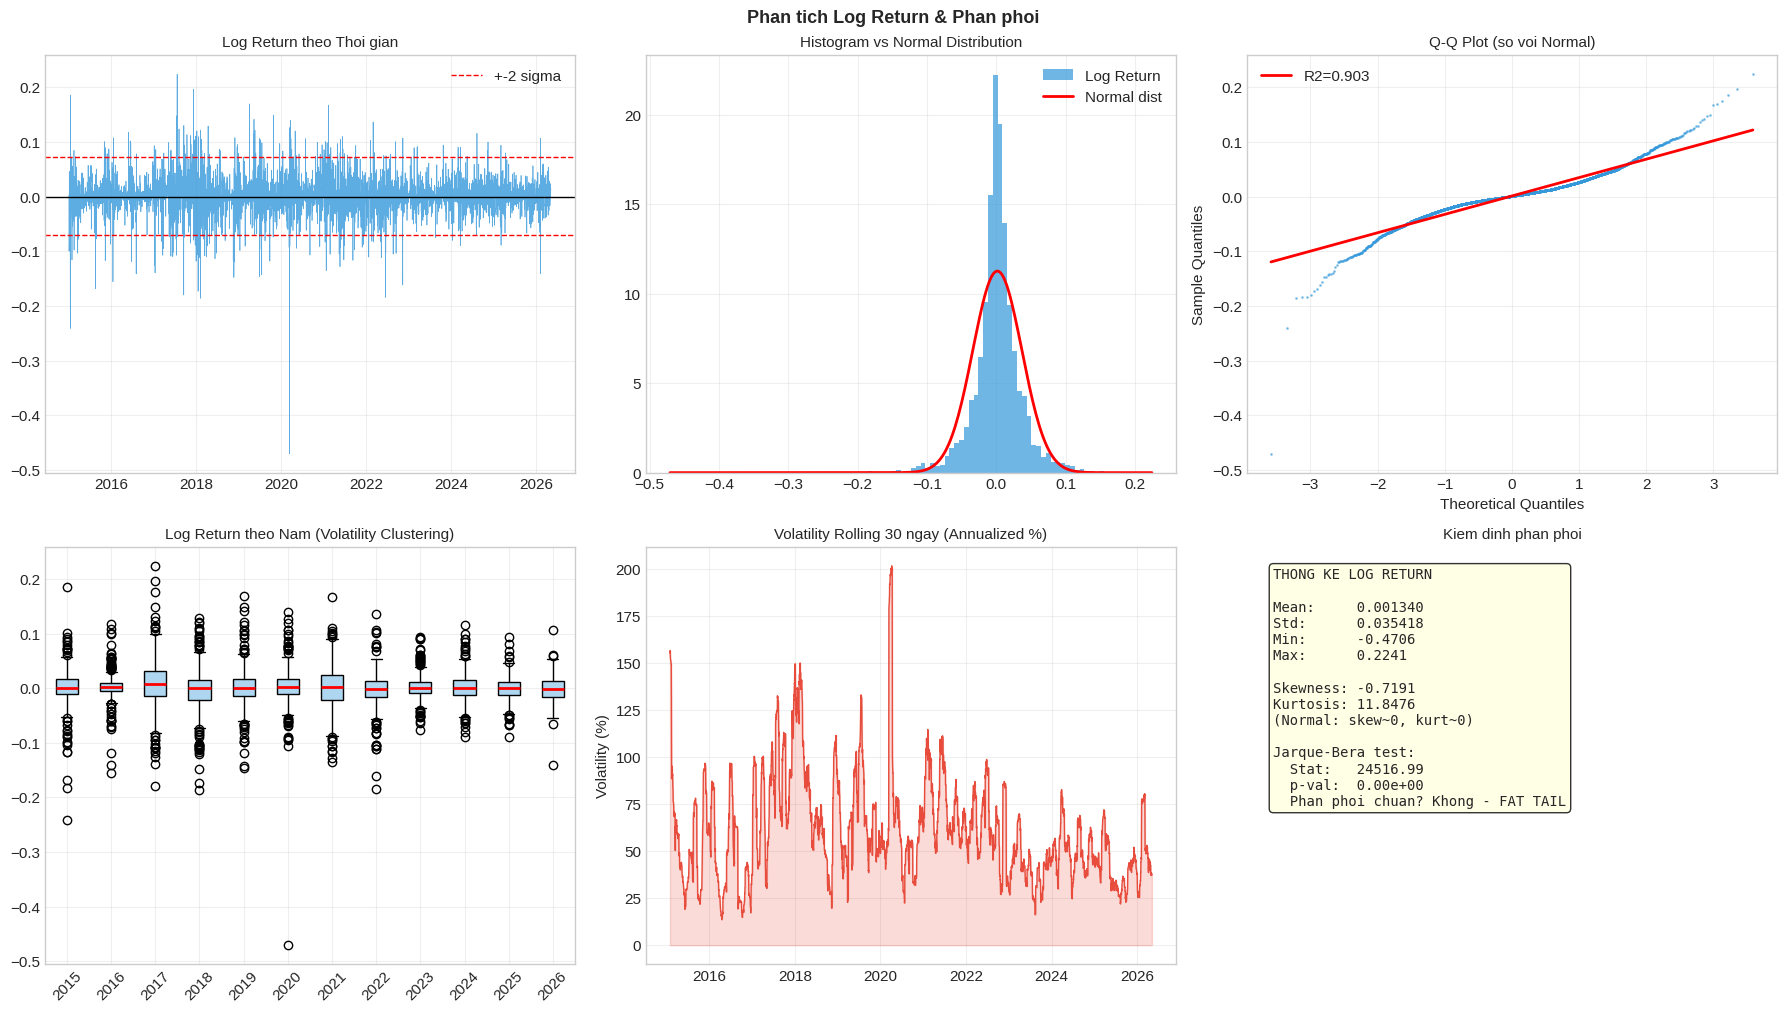


NHAN XET QUAN TRONG:
  Log return KHONG phan phoi chuan (Jarque-Bera reject H0)
  Kurtosis >> 0 -> FAT TAIL: cac ngay bien dong lon xay ra nhieu hon phan phoi chuan
  Skewness < 0  -> lech trai: cac cu giam manh (crash) xay ra nhieu hon tang cung bien do
  Volatility Clustering: giai doan cao keo theo cao tiep (2017, 2021)
  -> Day la ly do cac mo hinh GARCH duoc dung cho time series tai chinh



In [32]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
lr = df["log_return"].dropna()

# 1: Time series
ax = axes[0, 0]
ax.plot(df["date"], df["log_return"], color="#3498DB", lw=0.5, alpha=0.8)
ax.axhline(0, color="black", lw=1)
ax.axhline(lr.mean() + 2*lr.std(), color="red", ls="--", lw=1, label="+-2 sigma")
ax.axhline(lr.mean() - 2*lr.std(), color="red", ls="--", lw=1)
ax.set_title("Log Return theo Thoi gian", fontsize=11)
ax.legend(); ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# 2: Histogram vs Normal
ax = axes[0, 1]
ax.hist(lr, bins=100, density=True, color="#3498DB", alpha=0.7, label="Log Return")
x = np.linspace(lr.min(), lr.max(), 300)
ax.plot(x, stats.norm.pdf(x, lr.mean(), lr.std()), "r-", lw=2, label="Normal dist")
ax.set_title("Histogram vs Normal Distribution", fontsize=11)
ax.legend()

# 3: QQ Plot
# 3: QQ Plot
ax = axes[0, 2]
(osm, osr), (slope, intercept, r) = stats.probplot(lr, dist="norm")
ax.scatter(osm, osr, s=1, color="#3498DB", alpha=0.5)
ax.plot(osm, slope*np.array(osm)+intercept, "r-", lw=2, label=f"R2={r**2:.3f}")
ax.set_title("Q-Q Plot (so voi Normal)", fontsize=11)
ax.set_xlabel("Theoretical Quantiles"); ax.set_ylabel("Sample Quantiles")
ax.legend()

# 4: Box plot theo nam
ax = axes[1, 0]
years = sorted(df["year"].unique())
data_by_year = [df[df["year"]==y]["log_return"].dropna().values for y in years]
bp = ax.boxplot(data_by_year, labels=years, patch_artist=True,
                medianprops=dict(color="red", lw=2))
for patch in bp["boxes"]: patch.set_facecolor("#AED6F1")
ax.set_title("Log Return theo Nam (Volatility Clustering)", fontsize=11)
ax.tick_params(axis="x", rotation=45)

# 5: Rolling Volatility
ax = axes[1, 1]
roll_vol = df["log_return"].rolling(30).std() * np.sqrt(365) * 100
ax.plot(df["date"], roll_vol, color="#E74C3C", lw=1)
ax.fill_between(df["date"], roll_vol, alpha=0.2, color="#E74C3C")
ax.set_title("Volatility Rolling 30 ngay (Annualized %)", fontsize=11)
ax.set_ylabel("Volatility (%)"); ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# 6: Stats text
ax = axes[1, 2]
jb_stat, jb_p = jarque_bera(lr)
text = (f"THONG KE LOG RETURN\n\n"
        f"Mean:     {lr.mean():.6f}\n"
        f"Std:      {lr.std():.6f}\n"
        f"Min:      {lr.min():.4f}\n"
        f"Max:      {lr.max():.4f}\n\n"
        f"Skewness: {lr.skew():.4f}\n"
        f"Kurtosis: {lr.kurtosis():.4f}\n"
        f"(Normal: skew~0, kurt~0)\n\n"
        f"Jarque-Bera test:\n"
        f"  Stat:   {jb_stat:.2f}\n"
        f"  p-val:  {jb_p:.2e}\n"
        f"  Phan phoi chuan? {'Co' if jb_p>0.05 else 'Khong - FAT TAIL'}")
ax.text(0.05, 0.95, text, transform=ax.transAxes, fontsize=10,
        verticalalignment="top", fontfamily="monospace",
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))
ax.axis("off"); ax.set_title("Kiem dinh phan phoi", fontsize=11)

plt.tight_layout()
plt.suptitle("Phan tich Log Return & Phan phoi", y=1.01, fontsize=13, fontweight="bold")
plt.show()

print("""
NHAN XET QUAN TRONG:
  Log return KHONG phan phoi chuan (Jarque-Bera reject H0)
  Kurtosis >> 0 -> FAT TAIL: cac ngay bien dong lon xay ra nhieu hon phan phoi chuan
  Skewness < 0  -> lech trai: cac cu giam manh (crash) xay ra nhieu hon tang cung bien do
  Volatility Clustering: giai doan cao keo theo cao tiep (2017, 2021)
  -> Day la ly do cac mo hinh GARCH duoc dung cho time series tai chinh
""")

---
## 9. Phân Rã Chuỗi Thời Gian (STL Decomposition)

> Phân rã thành 3 thành phần: **Trend** (xu hướng) + **Seasonal** (mùa vụ) + **Residual** (nhiễu)
>
> Dùng **STL** — robust với outliers, phù hợp BTC.

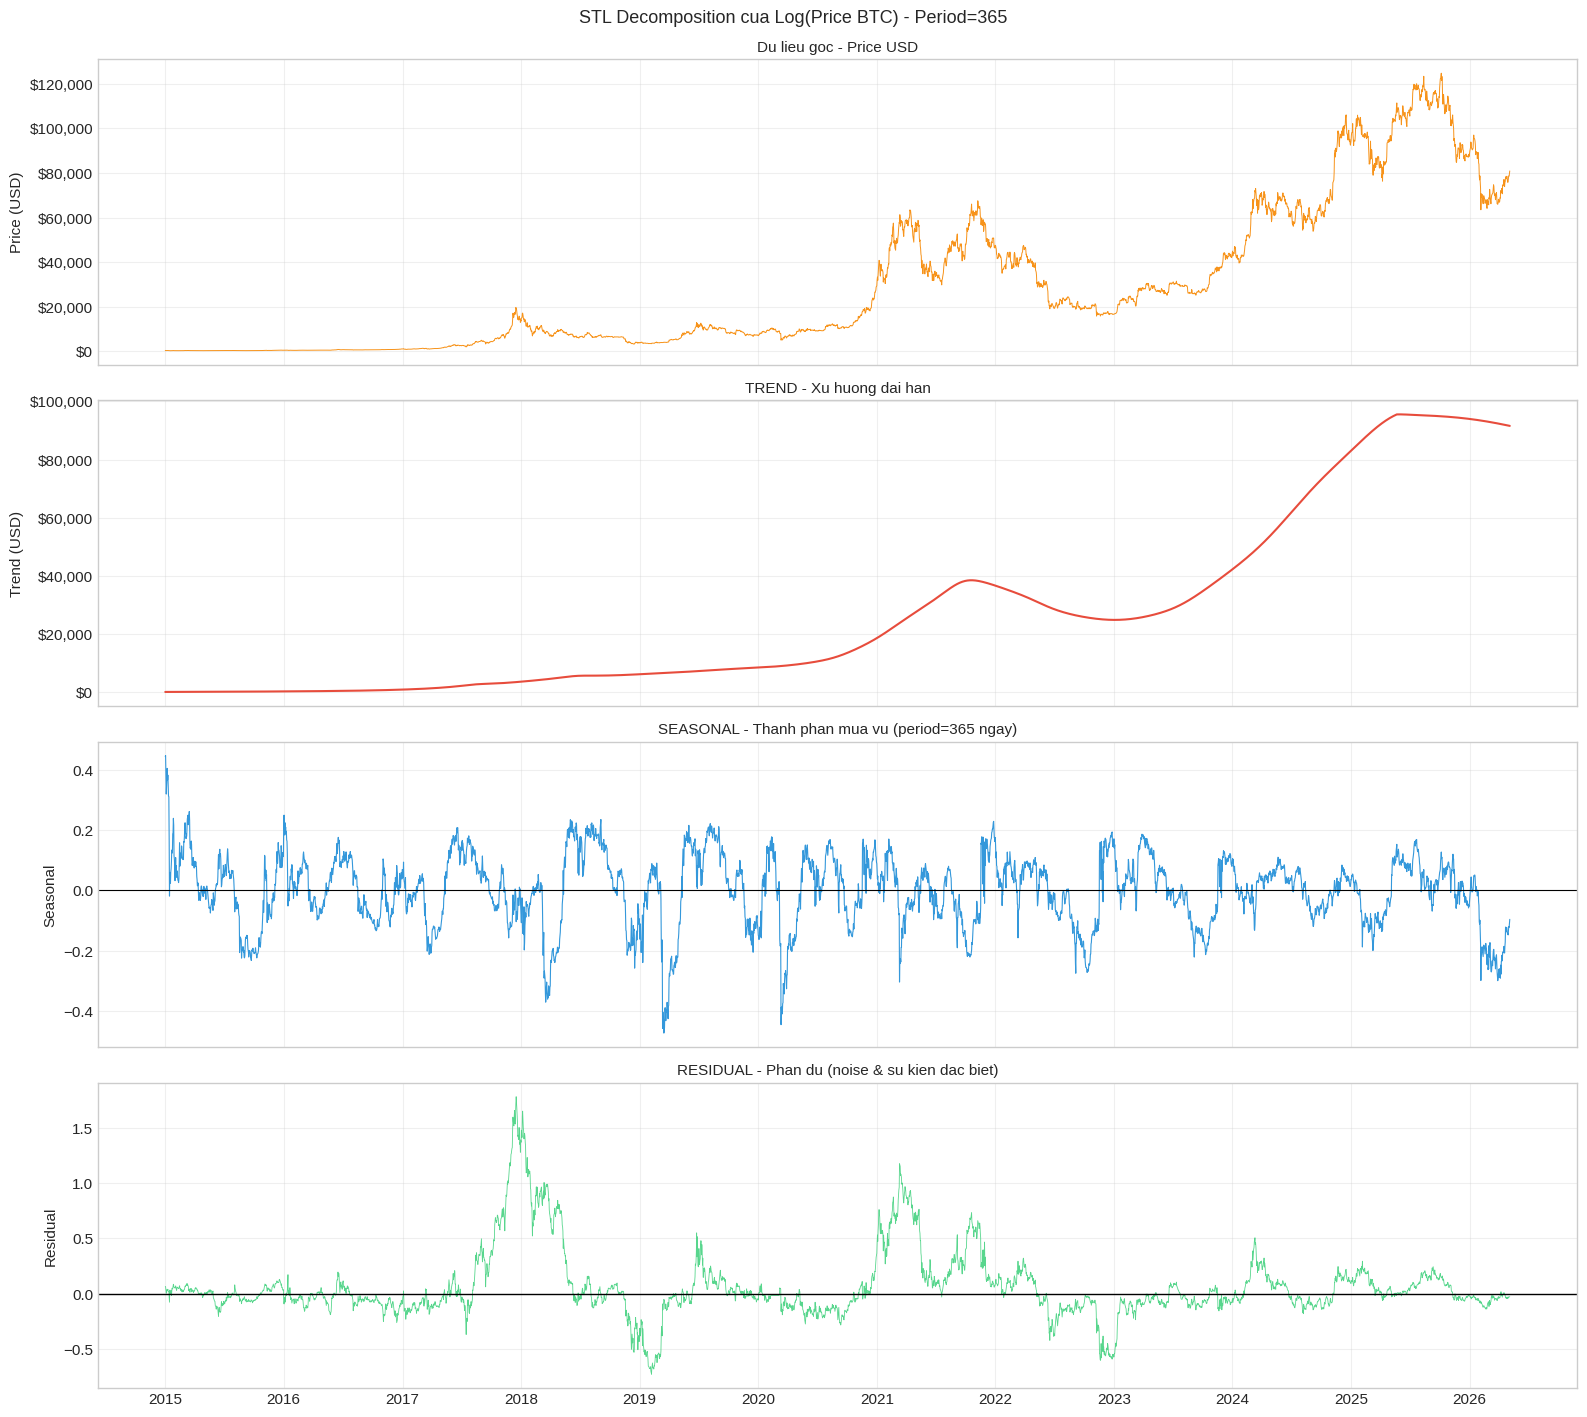

Trend contribution   : 96.9%
Seasonal contribution: 0.4%
Residual contribution: 2.7%

NHAN XET:
  Trend chiem ty le lon -> BTC co xu huong ro rang dai han (bull/bear cycles 4 nam)
  Seasonal nho -> khong co mua vu ro ret nhu co phieu truyen thong
  Residual lon -> bien dong ngau nhien cao, thi truong kho doan
  -> Trend component la feature quan trong cho mo hinh du doan



In [33]:
from statsmodels.tsa.seasonal import STL
import numpy as np

log_price = np.log(df.set_index("date")["price_usd"])
stl = STL(log_price, period=365, robust=True)
result = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)

axes[0].plot(log_price.index, np.exp(log_price), color="#F7931A", lw=0.7)
axes[0].set_title("Du lieu goc - Price USD", fontsize=11)
axes[0].set_ylabel("Price (USD)")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"${x:,.0f}"))

axes[1].plot(log_price.index, np.exp(result.trend), color="#E74C3C", lw=1.5)
axes[1].set_title("TREND - Xu huong dai han", fontsize=11)
axes[1].set_ylabel("Trend (USD)")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"${x:,.0f}"))

axes[2].plot(log_price.index, result.seasonal, color="#3498DB", lw=0.8)
axes[2].axhline(0, color="black", lw=0.8)
axes[2].set_title("SEASONAL - Thanh phan mua vu (period=365 ngay)", fontsize=11)
axes[2].set_ylabel("Seasonal")

axes[3].plot(log_price.index, result.resid, color="#2ECC71", lw=0.6, alpha=0.8)
axes[3].axhline(0, color="black", lw=1)
axes[3].set_title("RESIDUAL - Phan du (noise & su kien dac biet)", fontsize=11)
axes[3].set_ylabel("Residual")

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.suptitle("STL Decomposition cua Log(Price BTC) - Period=365", y=1.01, fontsize=13)
plt.show()

trend_str    = np.var(result.trend)
seasonal_str = np.var(result.seasonal)
resid_str    = np.var(result.resid)
total        = trend_str + seasonal_str + resid_str
print(f"Trend contribution   : {trend_str/total*100:.1f}%")
print(f"Seasonal contribution: {seasonal_str/total*100:.1f}%")
print(f"Residual contribution: {resid_str/total*100:.1f}%")
print("""
NHAN XET:
  Trend chiem ty le lon -> BTC co xu huong ro rang dai han (bull/bear cycles 4 nam)
  Seasonal nho -> khong co mua vu ro ret nhu co phieu truyen thong
  Residual lon -> bien dong ngau nhien cao, thi truong kho doan
  -> Trend component la feature quan trong cho mo hinh du doan
""")

---
## 10. Phân Tích Đa Biến (Multivariate Analysis)

### 10.1 Ma trận tương quan Pearson

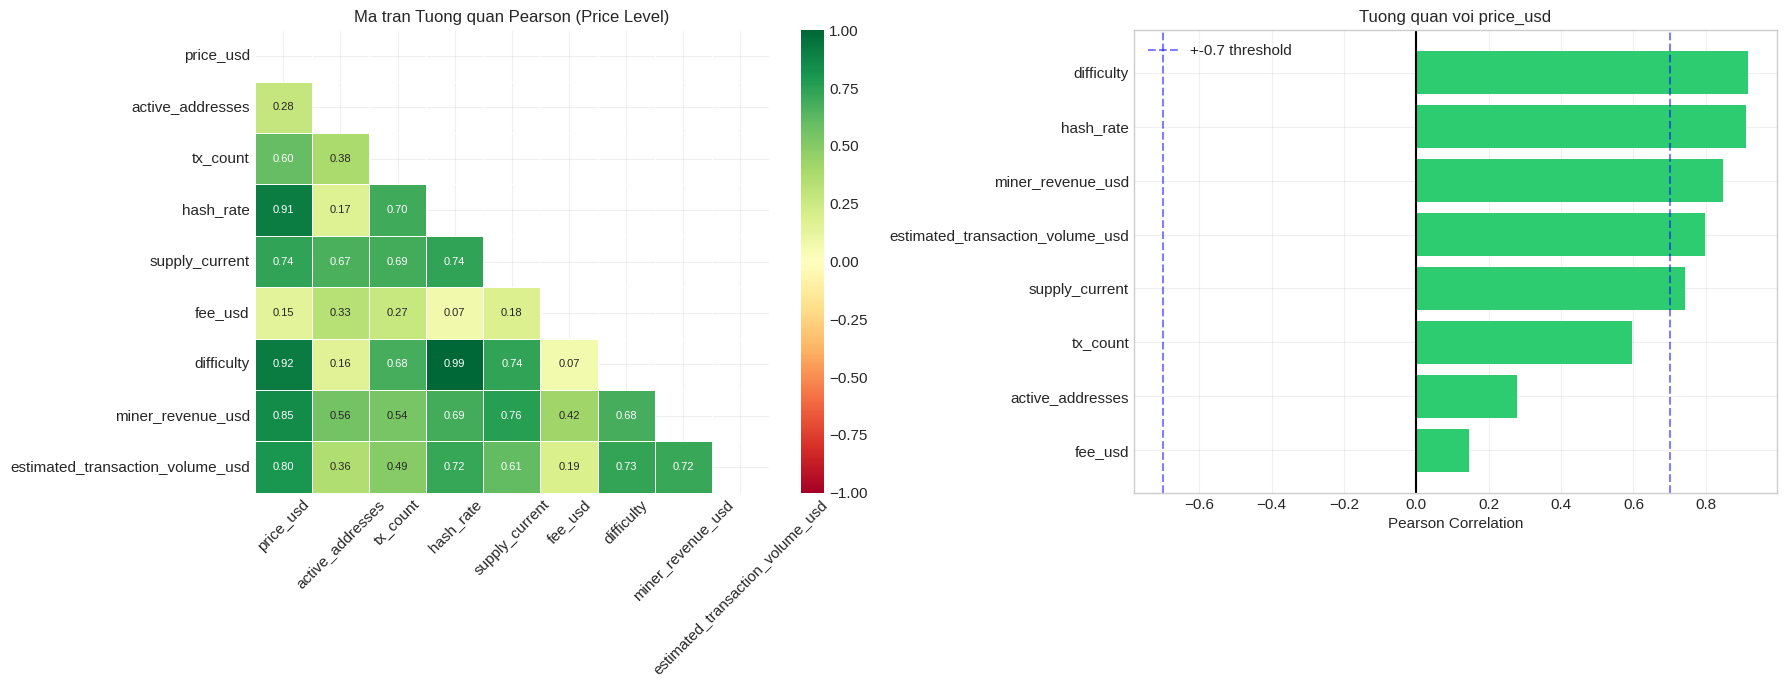


NHAN XET TUONG QUAN VOI PRICE:
  difficulty & hash_rate (r > 0.9): Rat cao - khi gia tang, nhieu tho dao tham gia
  miner_revenue & tx_volume (r > 0.8): Cao - hoat dong mang tuong quan voi gia
  supply_current (r ~ 0.74): CANH BAO - day co the la spurious correlation!
  active_addresses (r ~ 0.28): Thap - khong tuong quan tot trong dai han
  fee_usd (r ~ 0.15): Yeu - phi phu thuoc congestion hon la gia

CANH BAO QUAN TRONG:
  Tuong quan Pearson cao voi price CO THE la spurious correlation (tuong quan gia)
  vi ca 2 chuoi deu co trend tang. Can dung correlation tren log-return!



In [34]:
numeric_cols = ["price_usd","active_addresses","tx_count","hash_rate",
                "supply_current","fee_usd","difficulty",
                "miner_revenue_usd","estimated_transaction_volume_usd"]

corr_matrix = df[numeric_cols].corr(method="pearson")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

import numpy as np
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, vmin=-1, vmax=1, ax=axes[0],
            linewidths=0.5, annot_kws={"size": 8})
axes[0].set_title("Ma tran Tuong quan Pearson (Price Level)", fontsize=12)
axes[0].tick_params(axis="x", rotation=45)

corr_price = corr_matrix["price_usd"].drop("price_usd").sort_values()
colors = ["#E74C3C" if v < 0 else "#2ECC71" for v in corr_price]
axes[1].barh(corr_price.index, corr_price, color=colors)
axes[1].axvline(0, color="black")
axes[1].axvline(0.7, color="blue", ls="--", alpha=0.5, label="+-0.7 threshold")
axes[1].axvline(-0.7, color="blue", ls="--", alpha=0.5)
axes[1].set_title("Tuong quan voi price_usd", fontsize=12)
axes[1].set_xlabel("Pearson Correlation")
axes[1].legend()

plt.tight_layout()
plt.show()

print("""
NHAN XET TUONG QUAN VOI PRICE:
  difficulty & hash_rate (r > 0.9): Rat cao - khi gia tang, nhieu tho dao tham gia
  miner_revenue & tx_volume (r > 0.8): Cao - hoat dong mang tuong quan voi gia
  supply_current (r ~ 0.74): CANH BAO - day co the la spurious correlation!
  active_addresses (r ~ 0.28): Thap - khong tuong quan tot trong dai han
  fee_usd (r ~ 0.15): Yeu - phi phu thuoc congestion hon la gia

CANH BAO QUAN TRONG:
  Tuong quan Pearson cao voi price CO THE la spurious correlation (tuong quan gia)
  vi ca 2 chuoi deu co trend tang. Can dung correlation tren log-return!
""")

### 10.2 Tương quan thực sự trên Log Return

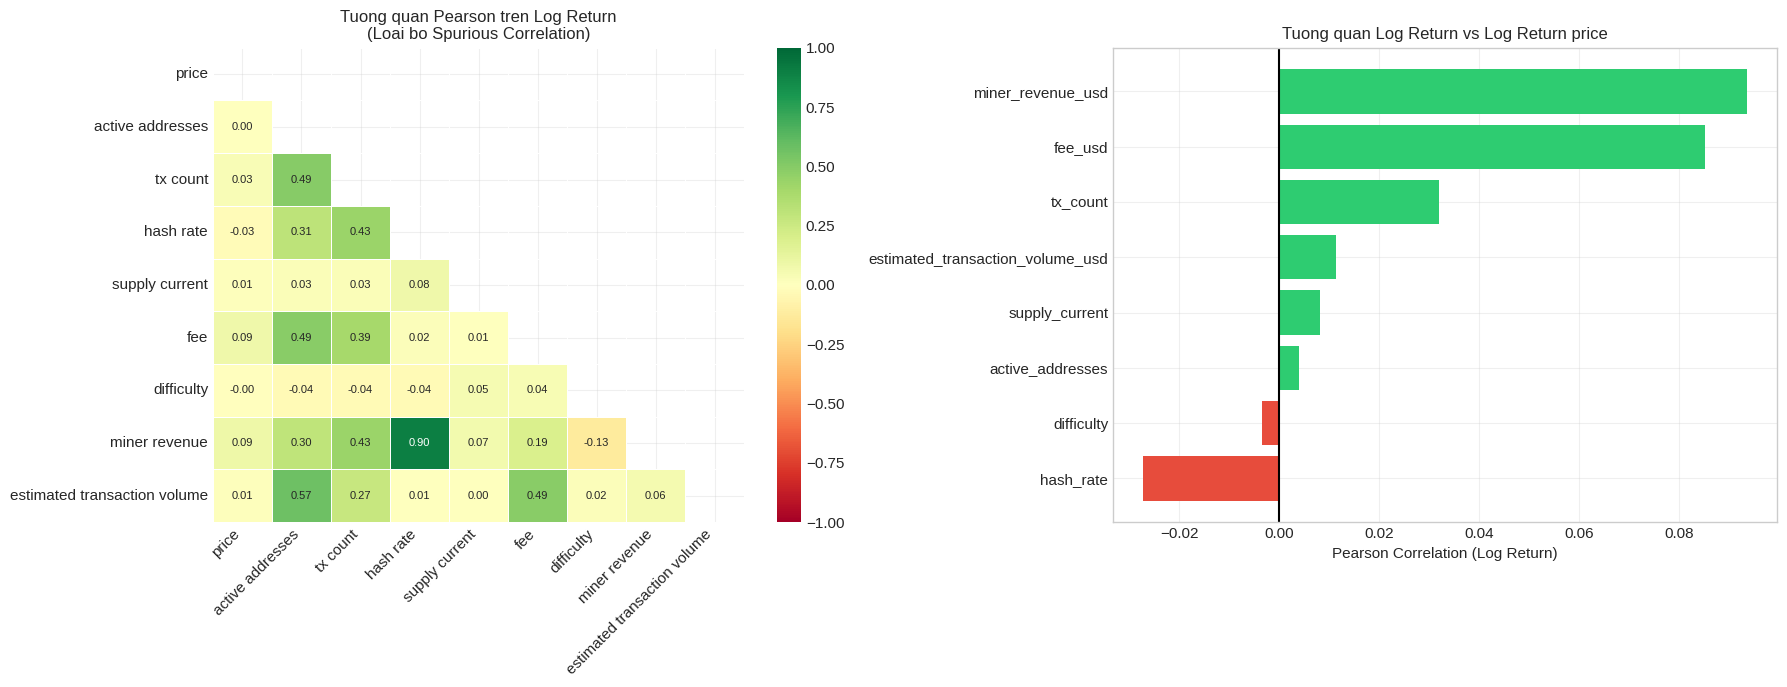


SO SANH 2 LOAI TUONG QUAN:
  Tuong quan Price Level: difficulty=0.916, hash_rate=0.912 (rat cao nhung co the spurious)
  Tuong quan Log Return : nhieu feature giam tuong quan manh sau khi remove trend

UNG DUNG: Uu tien features co tuong quan cao tren LOG RETURN khi build model du doan.



In [35]:
# Tinh log return cua tat ca features
log_return_df = np.log(df[numeric_cols]).diff().dropna()
log_return_df.columns = [f"lr_{c}" for c in numeric_cols]

corr_return = log_return_df.corr(method="pearson")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

mask2 = np.triu(np.ones_like(corr_return, dtype=bool))
sns.heatmap(corr_return, mask=mask2, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, vmin=-1, vmax=1, ax=axes[0],
            linewidths=0.5, annot_kws={"size": 8})
axes[0].set_title("Tuong quan Pearson tren Log Return\n(Loai bo Spurious Correlation)", fontsize=12)
tick_labels = [c.replace("lr_","").replace("_usd","").replace("_"," ") for c in log_return_df.columns]
axes[0].set_xticklabels(tick_labels, rotation=45, ha="right")
axes[0].set_yticklabels(tick_labels, rotation=0)

price_ret_corr = corr_return["lr_price_usd"].drop("lr_price_usd").sort_values()
colors2 = ["#E74C3C" if v < 0 else "#2ECC71" for v in price_ret_corr]
axes[1].barh(price_ret_corr.index.str.replace("lr_",""), price_ret_corr, color=colors2)
axes[1].axvline(0, color="black")
axes[1].set_title("Tuong quan Log Return vs Log Return price", fontsize=12)
axes[1].set_xlabel("Pearson Correlation (Log Return)")

plt.tight_layout()
plt.show()

print("""
SO SANH 2 LOAI TUONG QUAN:
  Tuong quan Price Level: difficulty=0.916, hash_rate=0.912 (rat cao nhung co the spurious)
  Tuong quan Log Return : nhieu feature giam tuong quan manh sau khi remove trend

UNG DUNG: Uu tien features co tuong quan cao tren LOG RETURN khi build model du doan.
""")

### 10.3 Lag Correlation — Feature nào có khả năng dự đoán giá tương lai?

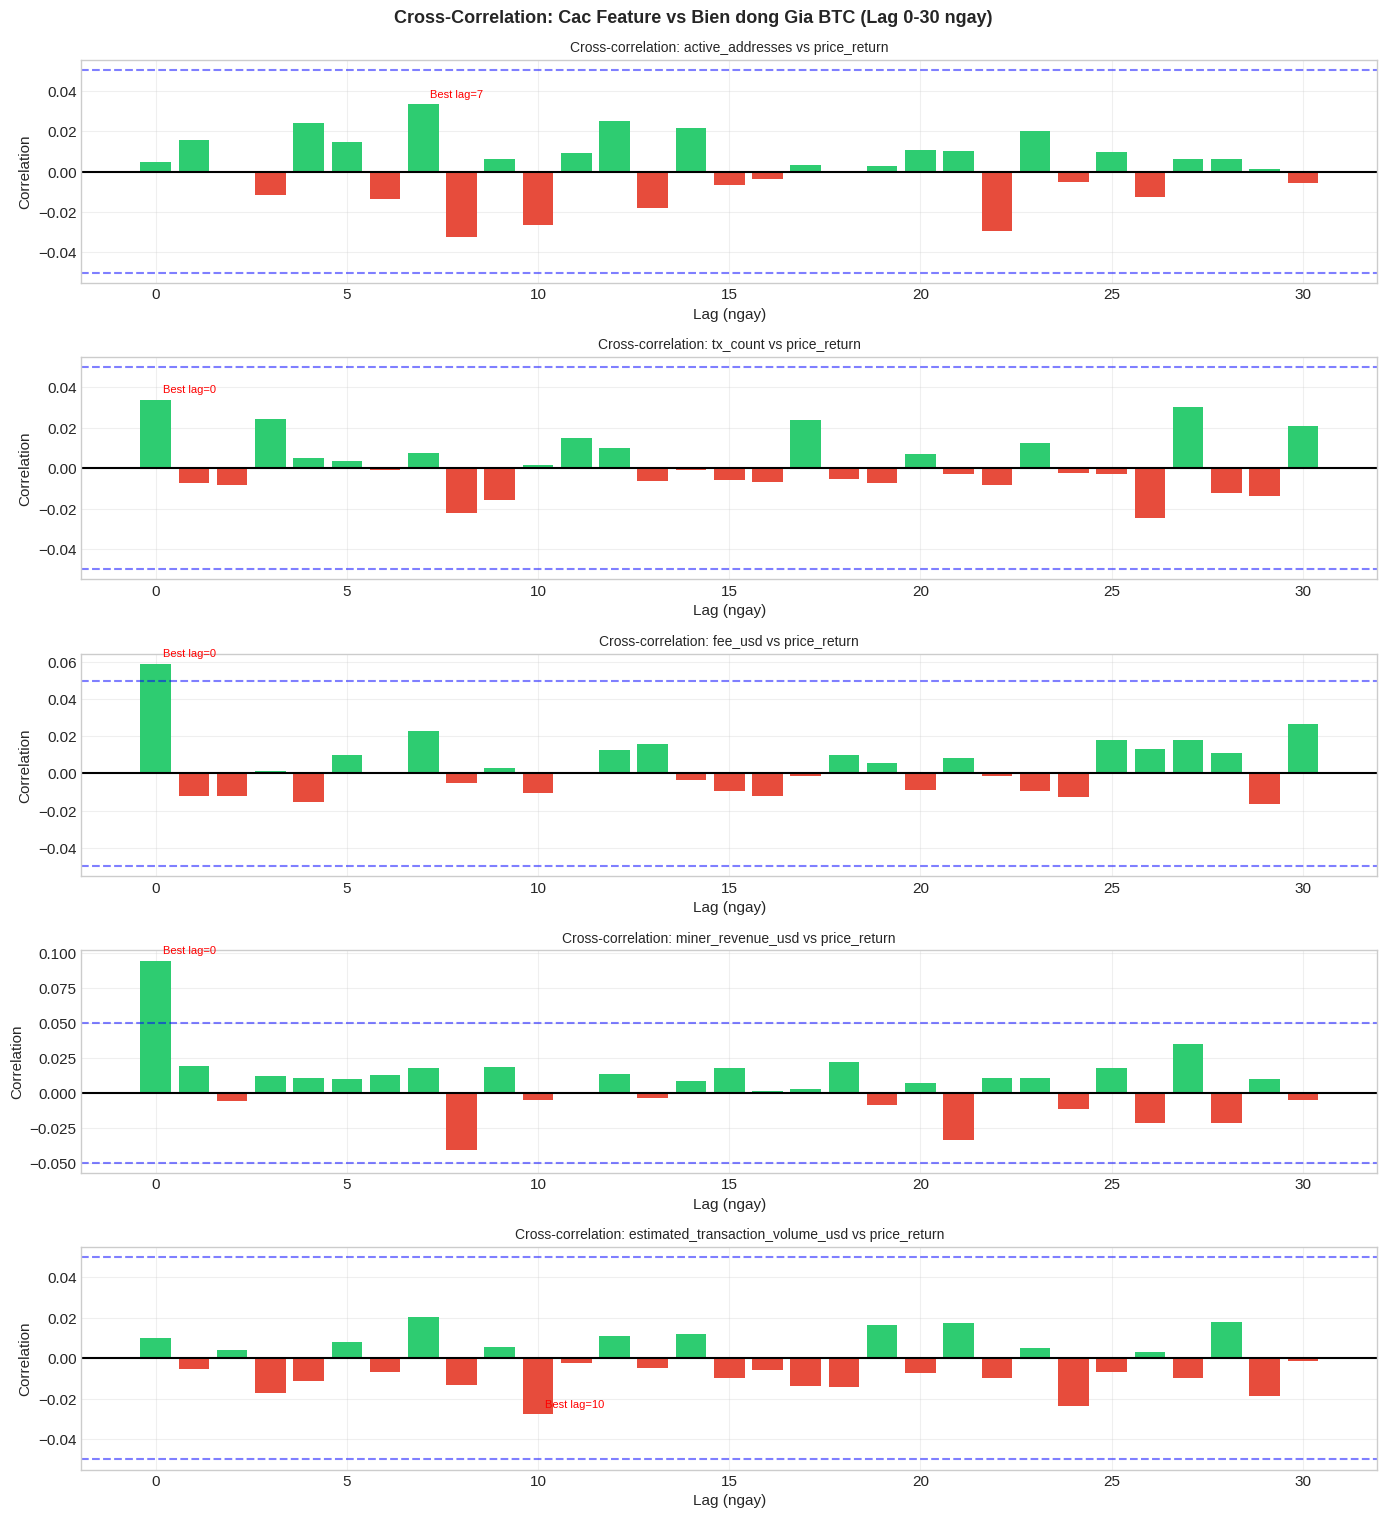


CACH DOC BIEU DO LAG CORRELATION:
  Lag 0: Tuong quan cung ngay
  Lag k: Feature hom nay (t) vs price ngay t+k -> feature CO THE du doan truoc gia
  Neu lag 1,2,3 co tuong quan cao -> feature do co predictive power!
  -> Day la nen tang quyet dinh lag features dua vao model ML



In [36]:
features_to_test = ["active_addresses","tx_count","fee_usd",
                    "miner_revenue_usd","estimated_transaction_volume_usd"]
lags = range(0, 31)

fig, axes = plt.subplots(len(features_to_test), 1, figsize=(14, 3*len(features_to_test)))

for i, feat in enumerate(features_to_test):
    lag_corrs = []
    for lag in lags:
        corr = df["log_return"].corr(df[feat].pct_change().shift(lag))
        lag_corrs.append(corr)
    
    ax = axes[i]
    ax.bar(lags, lag_corrs, color=["#E74C3C" if c < 0 else "#2ECC71" for c in lag_corrs], width=0.8)
    ax.axhline(0, color="black")
    ax.axhline(0.05, color="blue", ls="--", alpha=0.5)
    ax.axhline(-0.05, color="blue", ls="--", alpha=0.5)
    ax.set_title(f"Cross-correlation: {feat} vs price_return", fontsize=10)
    ax.set_xlabel("Lag (ngay)"); ax.set_ylabel("Correlation")
    best_lag = int(np.argmax(np.abs(lag_corrs)))
    ax.annotate(f"Best lag={best_lag}", xy=(best_lag, lag_corrs[best_lag]),
                xytext=(5,5), textcoords="offset points", fontsize=8, color="red")

plt.tight_layout()
plt.suptitle("Cross-Correlation: Cac Feature vs Bien dong Gia BTC (Lag 0-30 ngay)",
             y=1.01, fontsize=13, fontweight="bold")
plt.show()

print("""
CACH DOC BIEU DO LAG CORRELATION:
  Lag 0: Tuong quan cung ngay
  Lag k: Feature hom nay (t) vs price ngay t+k -> feature CO THE du doan truoc gia
  Neu lag 1,2,3 co tuong quan cao -> feature do co predictive power!
  -> Day la nen tang quyet dinh lag features dua vao model ML
""")

### 10.4 Heatmap Calendar — Seasonality

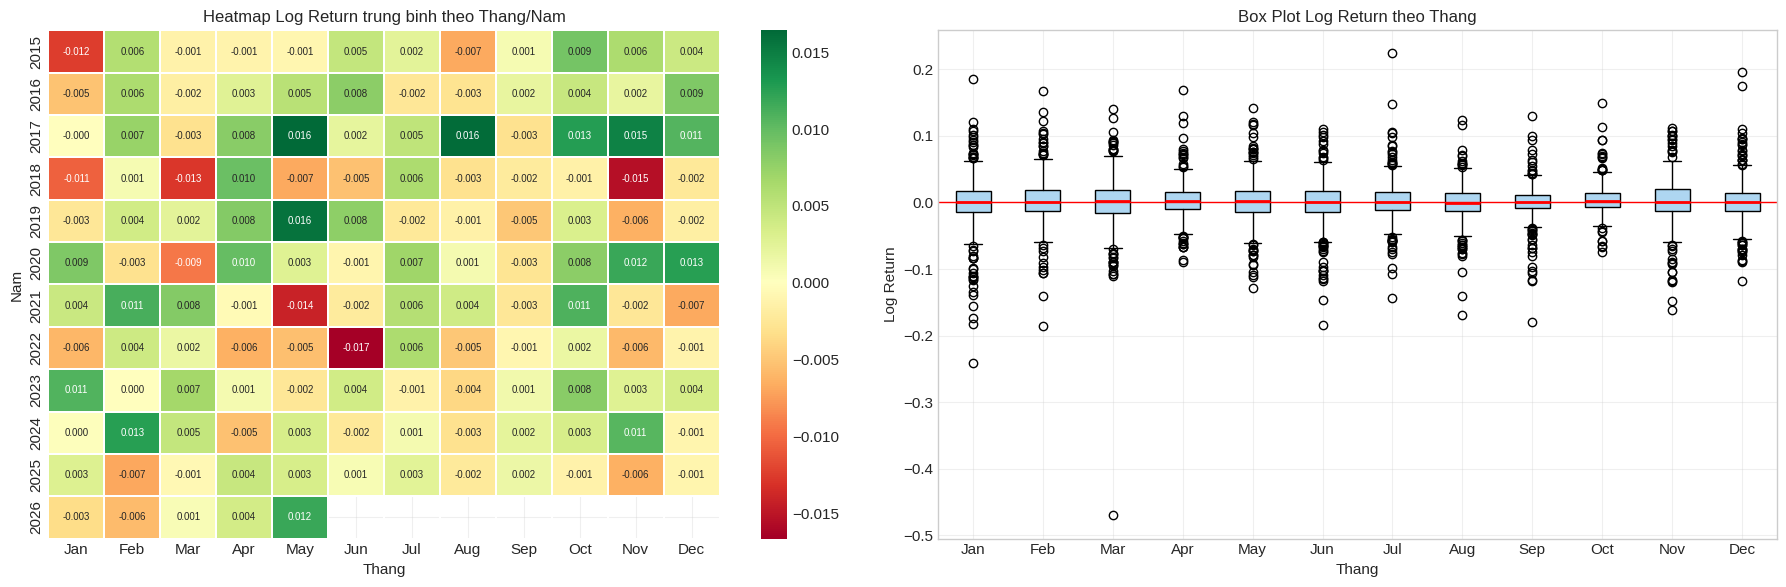


NHAN XET SEASONALITY:
  Thang 10, 11 lich su hay co return duong (Halloween effect)
  Thang 1, 6 co the am (profit taking va sell in May)
  Nhung khong co pattern mua vu du manh va nhat quan de du doan chinh xac
  -> BTC chu yeu bi drive boi sentiment, halving cycle, macro factors



In [37]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Heatmap return theo thang/nam
monthly_return = df.groupby(["year","month"])["log_return"].mean().unstack()
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
sns.heatmap(monthly_return, cmap="RdYlGn", center=0, annot=True, fmt=".3f",
            xticklabels=month_names, ax=axes[0], linewidths=0.3, annot_kws={"size":7})
axes[0].set_title("Heatmap Log Return trung binh theo Thang/Nam", fontsize=12)
axes[0].set_xlabel("Thang"); axes[0].set_ylabel("Nam")

# Box plot theo thang
months_data = [df[df["month"]==m]["log_return"].dropna().values for m in range(1,13)]
bp = axes[1].boxplot(months_data, labels=month_names, patch_artist=True,
                     medianprops=dict(color="red", lw=2))
for patch in bp["boxes"]: patch.set_facecolor("#AED6F1")
axes[1].axhline(0, color="red", lw=1)
axes[1].set_title("Box Plot Log Return theo Thang", fontsize=12)
axes[1].set_xlabel("Thang"); axes[1].set_ylabel("Log Return")

plt.tight_layout()
plt.show()

print("""
NHAN XET SEASONALITY:
  Thang 10, 11 lich su hay co return duong (Halloween effect)
  Thang 1, 6 co the am (profit taking va sell in May)
  Nhung khong co pattern mua vu du manh va nhat quan de du doan chinh xac
  -> BTC chu yeu bi drive boi sentiment, halving cycle, macro factors
""")

---
## 11. Tóm Tắt Kết Quả EDA & Gợi Ý Xây Dựng Mô Hình

In [38]:
print("""
+===========================================================+
|    TOM TAT KET QUA EDA - BTC ON-CHAIN TIME SERIES        |
+===========================================================+

DU LIEU:
  4,143 diem du lieu hang ngay: 2015-01-01 -> 2026-05-05
  Khong co null, duplicate, khoang trong thoi gian
  9 features on-chain + 1 target (price_usd)

TINH DUNG:
  price_usd   -> KHONG DUNG (ADF p=0.756)
  log_return  -> DUNG (ADF p~0)
  Phai bien doi du lieu truoc khi dung ARIMA

PHAN PHOI LOG RETURN:
  FAT TAIL (kurtosis~12), KHONG phan phoi chuan
  Volatility Clustering (giai doan bien dong cao keo dai)
  -> Can mo hinh xu ly fat tail (GARCH, Quantile regression)

TUONG QUAN VOI PRICE (LEVEL - CO THE SPURIOUS):
  difficulty    = 0.916
  hash_rate     = 0.912
  miner_revenue = 0.847
  tx_volume     = 0.797

TUONG QUAN THUC SU (LOG RETURN):
  -> Giam dang ke sau khi remove trend
  -> Can kiem tra lai de chon feature cho model

SEASONALITY:
  Khong co mua vu ro rang va nhat quan
  Chu ky bull/bear 4 nam (lien quan halving)

===========================================================

GQI Y XAY DUNG MO HINH DU DOAN GIA BTC:

1. FEATURE ENGINEERING:
   - Lag features: price_lag_1, lag_7, lag_14, lag_30
   - Rolling stats: rolling_mean_7d, rolling_std_30d, rolling_mean_90d
   - Log return cua tat ca features
   - Calendar: year, month, quarter
   - Trend component tu STL

2. TRAIN/TEST SPLIT (KHONG RANDOM!):
   Dung chronological split:
   Train: 2015-2022 | Val: 2023 | Test: 2024-2026

3. PREPROCESSING:
   - Scale SAU khi split
   - Fit scaler CHI tren train set
   - Transform ca train + val + test

4. MO HINH DE XUAT:
   Baseline  : Linear Regression voi lag features
   Statistical: ARIMA(p,d,q) tren log_return
   ML        : XGBoost, LightGBM voi lag & rolling features
   DL        : LSTM, GRU (sequence models)
   Ensemble  : Stack nhieu model

5. METRICS DANH GIA:
   MAE  - Mean Absolute Error
   RMSE - Root Mean Squared Error
   MAPE - Mean Absolute Percentage Error (%)
   DA   - Directional Accuracy (% dung chieu tang/giam)
""")


+===========================================================+
|    TOM TAT KET QUA EDA - BTC ON-CHAIN TIME SERIES        |
+===========================================================+

DU LIEU:
  4,143 diem du lieu hang ngay: 2015-01-01 -> 2026-05-05
  Khong co null, duplicate, khoang trong thoi gian
  9 features on-chain + 1 target (price_usd)

TINH DUNG:
  price_usd   -> KHONG DUNG (ADF p=0.756)
  log_return  -> DUNG (ADF p~0)
  Phai bien doi du lieu truoc khi dung ARIMA

PHAN PHOI LOG RETURN:
  FAT TAIL (kurtosis~12), KHONG phan phoi chuan
  Volatility Clustering (giai doan bien dong cao keo dai)
  -> Can mo hinh xu ly fat tail (GARCH, Quantile regression)

TUONG QUAN VOI PRICE (LEVEL - CO THE SPURIOUS):
  difficulty    = 0.916
  hash_rate     = 0.912
  miner_revenue = 0.847
  tx_volume     = 0.797

TUONG QUAN THUC SU (LOG RETURN):
  -> Giam dang ke sau khi remove trend
  -> Can kiem tra lai de chon feature cho model

SEASONALITY:
  Khong co mua vu ro rang va nhat quan
  Chu ky bu